In [29]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf

In [30]:
force                        = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, 'force.session.success.tsv'), sep='\t')
force                        = force[force.session.isin([3, 9, 23])].reset_index(drop=True)
force_trained                = force[force.chord=='trained'].reset_index(drop=True)
force_untrained              = force[force.chord=='untrained'].reset_index(drop=True)
force_diff                   = force_trained.copy()
force_diff                   = force_diff.merge(force_untrained, on=['subNum', 'session'])
force_diff['force_abs']      = force_diff.force_abs_x - force_diff.force_abs_y
force_diff['force_der']      = force_diff.force_der_x - force_diff.force_der_y
force_diff['force_der_peak'] = force_diff.force_der_peak_x - force_diff.force_der_peak_y

In [31]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'nanmean'
act              = pd.read_csv(os.path.join(gl.baseDir, f'glm{glm}', 'ROI.activation.tsv'), sep='\t')
act              = act.groupby(['chord', 'session', 'sn', 'regionname', 'Hem']).mean(numeric_only=True).reset_index()
act_trained      = act[act.chord=='trained'].reset_index(drop=True)
act_untrained    = act[act.chord=='untrained'].reset_index(drop=True)
act_diff         = act_trained.copy()
act_diff         = act_diff.merge(act_untrained, on=['session', 'sn', 'regionname', 'Hem'])
act_diff['Diff'] = act_diff[f'{stat}_x'] - act_diff[f'{stat}_y']

act_diff = act_diff[act_diff.sn!=117]

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3   0.514695 -0.103339  1.132728  1.832968  0.093987
3         PMd        3   0.288802 -0.691291  1.268895  0.648559  0.529930
6         PMv        3  -0.061802 -0.391334  0.267731 -0.412782  0.687698
9          M1        3  -0.180606 -0.912822  0.551610 -0.542888  0.598035
12         S1        3   0.047327 -0.753957  0.848611  0.129999  0.898914
15       SPLa        3   0.147766 -0.834061  1.129592  0.331250  0.746680
18       SPLp        3   0.424461 -0.520169  1.369091  0.988993  0.343923
1         SMA        9  -0.909096 -1.421691 -0.396501 -3.903484  0.002462
4         PMd        9  -2.492753 -3.578547 -1.406958 -5.052992  0.000370
7         PMv        9  -1.045868 -1.792917 -0.298818 -3.081373  0.010446
10         M1        9  -0.985838 -2.157107  0.185432 -1.852532  0.090950
13         S1        9  -1.714225 -3.312006 -0.116444 -2.361390  0.037721
16       SPLa        9  -3.209081 -4.7

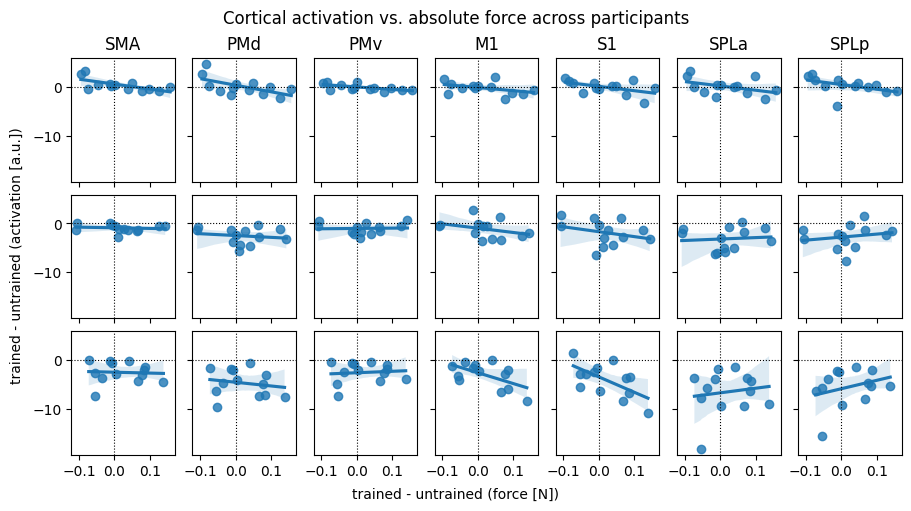

In [32]:
session   = act_diff.session.unique()
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = act_diff[(act_diff.Hem==H) & (act_diff.regionname==roi) & (act_diff.session==sess)].Diff.to_numpy()
                x    = force_diff[force_diff.session==sess].force_abs.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force [N])', fontsize=10)

fig.suptitle('Cortical activation vs. absolute force across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

   regionname  session  intercept     ci_low   ci_high      tval      pval
0         SMA        3   0.266198  -0.431509  0.963906  0.839749  0.418927
3         PMd        3  -0.074335  -1.034906  0.886235 -0.170327  0.867845
6         PMv        3  -0.180716  -0.553296  0.191864 -1.067564  0.308587
9          M1        3  -0.294606  -1.090619  0.501406 -0.814591  0.432589
12         S1        3  -0.174046  -1.010576  0.662484 -0.457930  0.655916
15       SPLa        3  -0.109011  -1.019512  0.801491 -0.263515  0.797025
18       SPLp        3   0.177613  -0.780632  1.135858  0.407958  0.691132
1         SMA        9  -0.429765  -1.027943  0.168414 -1.581309  0.142113
4         PMd        9  -1.558651  -2.877374 -0.239928 -2.601432  0.024631
7         PMv        9  -0.804646  -1.868118  0.258825 -1.665314  0.124042
10         M1        9  -0.345349  -2.001637  1.310939 -0.458923  0.655225
13         S1        9  -0.611028  -2.737250  1.515195 -0.632513  0.539977
16       SPLa        9  -

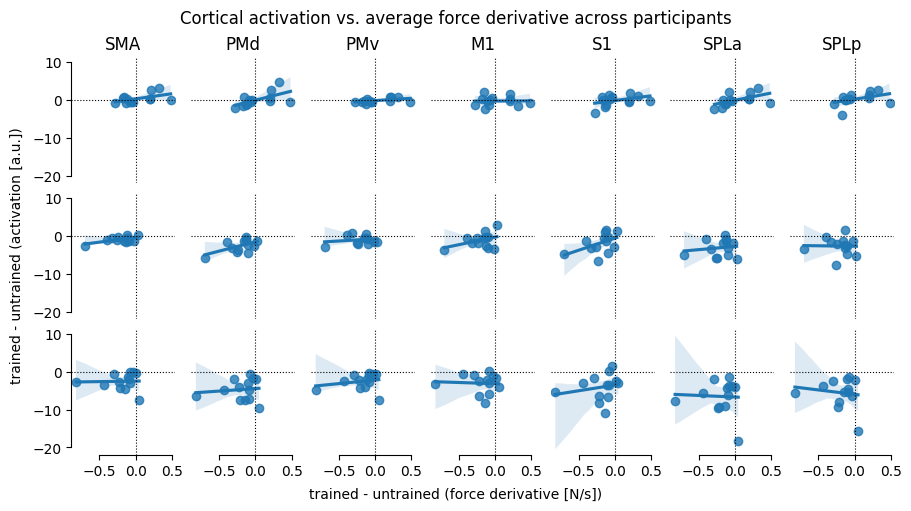

In [33]:
session   = act_diff.session.unique()
rois      = gl.rois[atlas]
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = act_diff[(act_diff.Hem==H) & (act_diff.regionname==roi) & (act_diff.session==sess)].Diff.to_numpy()
                x    = force_diff[force_diff.session==sess].force_der.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')


for r in range(len(rois)):
        for s in range(len(session)):
                ax = axs[s, r]
                sb.despine(ax=ax, trim=True, bottom=s < len(session)-1, left=r > 0)
                ax.tick_params(bottom=s == len(session)-1, left=r == 0)

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force derivative [N/s])', fontsize=10)

fig.suptitle('Cortical activation vs. average force derivative across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

fig.savefig('figures/force_der_intercept.pdf')

plt.show()

NameError: name 'diff_force' is not defined

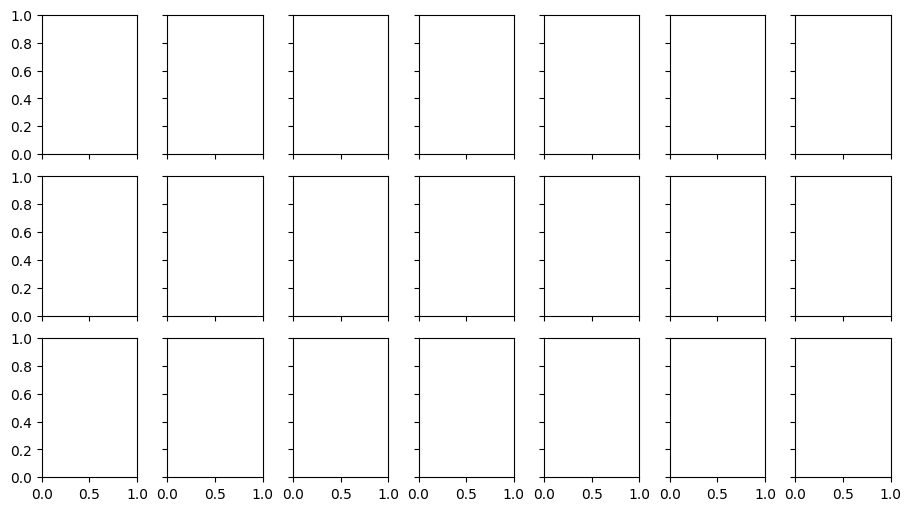

In [34]:
session   = act_diff.session.unique()
rois      = gl.rois[atlas]
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = act_diff[(act_diff.Hem==H) & (act_diff.regionname==roi) & (act_diff.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].force_der_peak.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force derivative [N/s])', fontsize=10)

fig.suptitle('Cortical activation vs. peak force derivative across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()